In [1]:
import gzip
import io
import json
import math
import os
import random
import re
import sys
import time
from collections import Counter, defaultdict

import numpy as np

import gensim
from gensim.models import Word2Vec, FastText, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from gensim.models.callbacks import CallbackAny2Vec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
MODEL_DIR = "models"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("python:", sys.version.split()[0])
print("gensim:", gensim.__version__)
print("numpy :", np.__version__)

python: 3.11.9
gensim: 4.4.0
numpy : 2.4.6


In [2]:
CONFIG = {
    # how much of the Assignment 3 training split to use.
    # 1000000 = all of it, as the assignment specifies.
    "train_sentences": 1000000,

    # ---- shared embedding hyper-parameters -------------------------------------------
    "vector_size": 100,
    "window": 5,
    "min_count": 5,
    "epochs": 5,
    "negative": 10,
    "workers": max(1, (os.cpu_count() or 4) - 1),

    # word2vec / fastText: 1 = skip-gram, 0 = CBOW.
    # Skip-gram is the better choice for a morphologically rich language with many rare words.
    "sg": 1,

    # fastText character n-gram range. Gujarati is an abugida: a written "character" is a
    # consonant plus its matras, and inflection happens in short word-final chunks, so a
    # slightly shorter range than gensim's 3-6 default captures suffixes better.
    "fasttext_min_n": 2,
    "fasttext_max_n": 5,

    # Doc2Vec: 1 = PV-DM (the distributed-memory model the linked tutorial uses), 0 = PV-DBOW
    "doc2vec_dm": 1,

    # ---- K-means ----------------------------------------------------------------------
    "n_clusters": 50,
    "kmeans_max_iter": 60,
    "kmeans_tol": 1e-5,
    "kmeans_n_init": 3,          # restarts; the lowest-inertia run wins
    "words_per_cluster": 20,     # required by the assignment
    "cluster_vocab_limit": None, # None = cluster the whole vocabulary

    # ---- sentence retrieval -------------------------------------------------------------
    "sif_a": 1e-3,               # smoothing constant of the SIF weighted-average encoder
    "n_examples": 6,             # qualitative examples to print
    "paraphrase_probe_n": 500,   # size of the synthetic retrieval probe in section 8
}
CONFIG

{'train_sentences': 1000000,
 'vector_size': 100,
 'window': 5,
 'min_count': 5,
 'epochs': 5,
 'negative': 10,
 'workers': 15,
 'sg': 1,
 'fasttext_min_n': 2,
 'fasttext_max_n': 5,
 'doc2vec_dm': 1,
 'n_clusters': 50,
 'kmeans_max_iter': 60,
 'kmeans_tol': 1e-05,
 'kmeans_n_init': 3,
 'words_per_cluster': 20,
 'cluster_vocab_limit': None,
 'sif_a': 0.001,
 'n_examples': 6,
 'paraphrase_probe_n': 500}

In [3]:
SEARCH_DIRS = [
    os.path.join("..", "Assignment - 3", "data"),
    os.path.join("..", "Assignment - 4", "data"),
    DATA_DIR,
]


def find_splits(dirs=SEARCH_DIRS):
    for d in dirs:
        paths = {name: os.path.join(d, "gu_%s.txt" % name)
                 for name in ("train", "dev", "test")}
        if all(os.path.exists(p) for p in paths.values()):
            return paths
    return None


SPLIT_PATHS = find_splits()
if SPLIT_PATHS:
    print("found the Assignment 3 splits in", os.path.dirname(SPLIT_PATHS["train"]))
else:
    print("splits not found - they will be rebuilt below")

found the Assignment 3 splits in ..\Assignment - 3\data


In [4]:
if SPLIT_PATHS is None:
    # ---- identical to Assignment 3: stream, sentence-tokenize, length-stratified split ----
    from huggingface_hub import HfApi, hf_hub_url
    import requests

    try:
        from huggingface_hub import get_token
    except ImportError:
        from huggingface_hub import HfFolder

        def get_token():
            return HfFolder.get_token()

    REPO_ID = "ai4bharat/IndicCorpV2"
    DANDA, DOUBLE_DANDA = "।", "॥"
    HARD_STOPS = DANDA + DOUBLE_DANDA + "…" + "!?"
    _HARD_SPLIT = re.compile(r"(?<=[" + re.escape(HARD_STOPS) + r"])\s+|\n+")
    _DOT_SPLIT = re.compile(r"(?<![A-Z]\.)(?<!\d\.)(?<=\.)\s+(?!\d)")
    _WS = re.compile(r"\s+")
    _URL = re.compile(r"https?://\S+|www\.\S+|\S+@\S+\.\S+")
    _GU_CHAR = re.compile("[઀-૿]")
    N_DEV = N_TEST = 1000
    TOTAL = CONFIG["train_sentences"] + N_DEV + N_TEST

    def _sentence_tokenize(paragraph):
        paragraph = _URL.sub(" ", paragraph)
        out = []
        for chunk in _HARD_SPLIT.split(paragraph):
            for piece in (_DOT_SPLIT.split(chunk) if chunk else ()):
                piece = _WS.sub(" ", piece).strip()
                if piece:
                    out.append(piece)
        return out

    def _acceptable(s):
        n = len(s)
        if n < 15 or n > 400 or s.count(" ") + 1 < 3:
            return False
        return len(_GU_CHAR.findall(s)) / n >= 0.5

    files = HfApi().list_repo_files(REPO_ID, repo_type="dataset")
    pat = re.compile(r"(?:^|/)(gu(?:[_-][A-Za-z]{4})?)\.txt(\.gz)?$")
    repo_path = min([p for p in files if pat.search(p)], key=len)
    print("streaming", repo_path)

    url = hf_hub_url(REPO_ID, repo_path, repo_type="dataset")
    token = get_token()
    headers = {"Authorization": "Bearer " + token} if token else {}
    seen, kept = set(), []
    with requests.get(url, headers=headers, stream=True, timeout=120) as resp:
        resp.raise_for_status()
        raw = gzip.GzipFile(fileobj=resp.raw) if repo_path.endswith(".gz") else resp.raw
        for line in io.TextIOWrapper(raw, encoding="utf-8", errors="ignore"):
            for s in _sentence_tokenize(line):
                if s not in seen and _acceptable(s):
                    seen.add(s)
                    kept.append(s)
            if len(kept) >= TOTAL:
                break
    kept = kept[:TOTAL]
    print("collected", len(kept), "sentences")

    lengths = np.array([s.count(" ") + 1 for s in kept])
    edges = np.quantile(lengths, np.linspace(0, 1, 11))
    edges[-1] += 1
    bin_of = np.clip(np.digitize(lengths, edges[1:-1]), 0, 9)
    rng = random.Random(SEED)
    buckets = defaultdict(list)
    for i, b in enumerate(bin_of):
        buckets[int(b)].append(i)
    dev_idx, test_idx = [], []
    for b in range(10):
        pool = buckets[b]
        rng.shuffle(pool)
        dev_idx += pool[:N_DEV // 10]
        test_idx += pool[N_DEV // 10:N_DEV // 10 + N_TEST // 10]
    held = set(dev_idx) | set(test_idx)
    parts = {"train": [kept[i] for i in range(len(kept)) if i not in held],
             "dev": [kept[i] for i in dev_idx],
             "test": [kept[i] for i in test_idx]}
    SPLIT_PATHS = {}
    for name, part in parts.items():
        path = os.path.join(DATA_DIR, "gu_%s.txt" % name)
        with io.open(path, "w", encoding="utf-8", newline="\n") as f:
            f.write("\n".join(part))
        SPLIT_PATHS[name] = path
    print("rebuilt and saved the splits")

In [5]:
_PRETOK = re.compile("[઀-૿]+|[A-Za-z]+|[0-9]+|[^\\s]")


def tokenize(sentence):
    return _PRETOK.findall(sentence)


class SentenceCorpus:
    """Restartable iterator over the tokenized sentences of a file."""

    def __init__(self, path, limit=None):
        self.path = path
        self.limit = limit
        self._len = None

    def __iter__(self):
        with io.open(self.path, encoding="utf-8") as f:
            for i, line in enumerate(f):
                if self.limit is not None and i >= self.limit:
                    break
                toks = tokenize(line.rstrip("\n"))
                if toks:
                    yield toks

    def __len__(self):
        if self._len is None:
            self._len = sum(1 for _ in self)
        return self._len


class TaggedCorpus:
    """The same corpus wrapped as TaggedDocuments, for Doc2Vec."""

    def __init__(self, corpus):
        self.corpus = corpus

    def __iter__(self):
        for i, toks in enumerate(self.corpus):
            yield TaggedDocument(toks, [i])


train_corpus = SentenceCorpus(SPLIT_PATHS["train"], limit=CONFIG["train_sentences"])


def read_sentences(path):
    with io.open(path, encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f if line.strip()]


dev_sents = read_sentences(SPLIT_PATHS["dev"])
test_sents = read_sentences(SPLIT_PATHS["test"])
dev_tokens = [tokenize(s) for s in dev_sents]
test_tokens = [tokenize(s) for s in test_sents]

print("dev %d   test %d sentences" % (len(dev_sents), len(test_sents)))
print("example:", dev_sents[0][:100])
print("tokens :", dev_tokens[0][:12])

dev 1000   test 1000 sentences
example: પ્રશ્નનો જવાબ આપવા માટે ઉતાવળના: "સમયમર્યાદા - કે તે" ન જોઈએ અ ફોરગોન કન્ક્લુઝન "છેલ્લા સમય".
tokens : ['પ્રશ્નનો', 'જવાબ', 'આપવા', 'માટે', 'ઉતાવળના', ':', '"', 'સમયમર્યાદા', '-', 'કે', 'તે', '"']


In [6]:
t0 = time.time()
n_sent = n_tok = 0
for toks in train_corpus:
    n_sent += 1
    n_tok += len(toks)
print("training corpus: {:,} sentences, {:,} tokens  ({:.0f}s to scan)".format(
    n_sent, n_tok, time.time() - t0))
print("average sentence length: %.1f tokens" % (n_tok / n_sent))

training corpus: 1,000,000 sentences, 17,135,144 tokens  (6s to scan)
average sentence length: 17.1 tokens


In [7]:
class EpochLogger(CallbackAny2Vec):
    """Prints one line per epoch, so a long training run shows progress."""

    def __init__(self, name):
        self.name = name
        self.epoch = 0
        self.t0 = None

    def on_epoch_begin(self, model):
        self.t0 = time.time()

    def on_epoch_end(self, model):
        self.epoch += 1
        print("    %s epoch %d/%d  (%.0fs)" % (
            self.name, self.epoch, model.epochs, time.time() - self.t0))


def train_or_load(name, builder, loader):
    path = os.path.join(MODEL_DIR, name)
    if os.path.exists(path):
        print("loading cached %s" % name)
        return loader(path)
    print("training %s ..." % name)
    t0 = time.time()
    model = builder()
    # gensim pickles the entire model on save(), the training callbacks included, and a
    # callback class defined in a notebook cell does not pickle reliably. Drop it first -
    # it has done its job by now anyway.
    model.callbacks = ()
    model.save(path)
    print("  trained in %.0fs -> %s" % (time.time() - t0, path))
    return model


def build_word2vec():
    return Word2Vec(
        sentences=train_corpus,
        vector_size=CONFIG["vector_size"],
        window=CONFIG["window"],
        min_count=CONFIG["min_count"],
        sg=CONFIG["sg"],
        negative=CONFIG["negative"],
        workers=CONFIG["workers"],
        epochs=CONFIG["epochs"],
        seed=SEED,
        callbacks=[EpochLogger("word2vec")],
    )


w2v = train_or_load("word2vec.model", build_word2vec, Word2Vec.load)
print("\nword2vec vocabulary: {:,} words".format(len(w2v.wv)))
print("vector size:", w2v.wv.vector_size)

loading cached word2vec.model

word2vec vocabulary: 112,487 words
vector size: 100


In [8]:
# the classic sanity check: what does the model think is similar to a frequent word?
def show_neighbours(kv, words, topn=8, label=""):
    for w in words:
        if w not in kv:
            print("  [%s] %-14s (not in vocabulary)" % (label, w))
            continue
        sims = kv.most_similar(w, topn=topn)
        print("  [%s] %-14s -> %s" % (
            label, w, ", ".join("%s (%.2f)" % (x, s) for x, s in sims)))


# a handful of common Gujarati words: "Gujarat", "India", "government", "city", "year", "woman"
PROBE_WORDS = ["ગુજરાત", "ભારત", "સરકાર", "શહેર", "વર્ષ", "મહિલા"]
# fall back to the most frequent words in the model if the probes are missing
PROBE_WORDS = [w for w in PROBE_WORDS if w in w2v.wv] or list(w2v.wv.index_to_key[10:16])

print("word2vec nearest neighbours")
show_neighbours(w2v.wv, PROBE_WORDS, label="w2v")

word2vec nearest neighbours
  [w2v] ગુજરાત         -> સૌરાષ્ટ્ર (0.77), મહારાષ્ટ્ર (0.75), હેમચંદ્રાચાર્ય (0.75), રાજ્ય (0.74), વિદ્યાભારતી (0.72), રાજય (0.71), કર્ણાટક (0.70), વડોદરાને (0.70)
  [w2v] ભારત           -> બાંગ્લાદેશ (0.81), પાકિસ્તાન (0.81), અમેરિકા (0.80), ચીન (0.80), ઇઝરાયલ (0.76), જાપાન (0.76), ભૂટાન (0.75), ઇઝરાઇલ (0.75)
  [w2v] સરકાર          -> સરકારો (0.81), સરકારને (0.78), સરકારની (0.78), સરકારે (0.77), સરકારોની (0.76), સરકારોને (0.74), સરકારના (0.74), સરકારોના (0.73)
  [w2v] શહેર           -> સૌરાષ્ટ્રનું (0.70), અંકલેશ્વર (0.67), સિહોર (0.67), બોટાદ (0.67), સિવાન (0.67), જીલ્લો (0.67), શહે૨ (0.67), મિરાણીના (0.66)
  [w2v] વર્ષ           -> મહિના (0.77), દાયકા (0.75), દશક (0.74), વર્ષો (0.72), મહીના (0.72), વરસ (0.71), ૨૦૦૪ (0.70), વર્ષમાં (0.70)
  [w2v] મહિલા          -> પુરુષ (0.71), મહીલા (0.70), અભયમ્ (0.69), મહિલાને (0.69), યુવતી (0.68), પુરૂષ (0.67), મહિલાઓ (0.67), હેલ્પલાઈનની (0.66)


In [9]:
def build_fasttext():
    return FastText(
        sentences=train_corpus,
        vector_size=CONFIG["vector_size"],
        window=CONFIG["window"],
        min_count=CONFIG["min_count"],
        sg=CONFIG["sg"],
        negative=CONFIG["negative"],
        workers=CONFIG["workers"],
        epochs=CONFIG["epochs"],
        min_n=CONFIG["fasttext_min_n"],
        max_n=CONFIG["fasttext_max_n"],
        seed=SEED,
        callbacks=[EpochLogger("fastText")],
    )


ft = train_or_load("fasttext.model", build_fasttext, FastText.load)
print("\nfastText vocabulary: {:,} words".format(len(ft.wv)))
print("character n-grams: %d..%d, %s buckets" % (
    CONFIG["fasttext_min_n"], CONFIG["fasttext_max_n"], "{:,}".format(ft.wv.bucket)))

loading cached fasttext.model

fastText vocabulary: 112,487 words
character n-grams: 2..5, 2,000,000 buckets


In [10]:
print("fastText nearest neighbours (compare with word2vec above)")
show_neighbours(ft.wv, PROBE_WORDS, label="ft")

fastText nearest neighbours (compare with word2vec above)
  [ft] ગુજરાત         -> મહાગુજરાત (0.84), ગુજરાતે (0.83), ગુજરાતઃ (0.82), ગુજરાતમા (0.81), ગુજરાતમિત્ર (0.81), સોરાષ્ટ્ર (0.81), સૌ૨ાષ્ટ્ર (0.80), સૌરાષ્ટ્ર (0.80)
  [ft] ભારત           -> પાકિસ્તાન (0.82), બાંગ્લાદેશ (0.82), ચીન (0.80), કઝાકિસ્તાન (0.80), અફધાનિસ્તાન (0.80), બાંગ્લાદેશથી (0.79), અફગાનિસ્તાન (0.79), અમેરિકા (0.79)
  [ft] સરકાર          -> સરકારો (0.87), સરકારનુ (0.84), રાજ્યસરકાર (0.83), સરકારમા (0.82), સરકારઃ (0.81), સરકારએ (0.81), સરકારની (0.80), સરકારથી (0.80)
  [ft] શહેર           -> શહેરા (0.83), શહે૨ (0.79), શહેરકોટડા (0.79), શહેરે (0.78), શહેરમા (0.76), શહેરામા (0.75), શહેરનુ (0.74), બુલંદશહેર (0.73)
  [ft] વર્ષ           -> વર્ષોવર્ષ (0.84), વર્ષમા (0.77), વર્ષો (0.77), વર્ષએ (0.77), ગતવર્ષ (0.76), મહિના (0.74), દાયકા (0.74), વર્ષમાં (0.72)
  [ft] મહિલા          -> મહિલામાં (0.74), મહીલા (0.72), મહિલાથી (0.72), પુરૂષ (0.71), પુરુષ (0.71), મહિલાનુ (0.70), મહિલાઓ (0.70), મહિલાના (0.70)


In [11]:
# The headline difference: out-of-vocabulary words.
oov = [w for toks in dev_tokens + test_tokens for w in toks if w not in w2v.wv]
oov_types = sorted(set(oov))
print("dev+test tokens outside the word2vec vocabulary: {:,} tokens, {:,} types".format(
    len(oov), len(oov_types)))

for w in oov_types[:5]:
    in_ft = w in ft.wv.key_to_index
    vec = ft.wv[w]                       # works whether or not the word was in the vocabulary
    near = ft.wv.most_similar(vec, topn=4)
    print("  %-16s w2v: MISSING | fastText: %s -> %s" % (
        w, "in vocab" if in_ft else "built from n-grams",
        ", ".join("%s (%.2f)" % (x, s) for x, s in near)))
if not oov_types:
    print("  (no OOV words in dev/test at this min_count)")

dev+test tokens outside the word2vec vocabulary: 1,382 tokens, 1,369 types
  075              w2v: MISSING | fastText: built from n-grams -> 072 (0.96), 073 (0.96), 085 (0.95), 070 (0.95)
  09256            w2v: MISSING | fastText: built from n-grams -> 092 (0.96), 888 (0.93), 756 (0.93), 856 (0.93)
  1252             w2v: MISSING | fastText: built from n-grams -> 1210 (0.96), 1296 (0.96), 1310 (0.95), 1233 (0.95)
  1340             w2v: MISSING | fastText: built from n-grams -> 1380 (0.98), 340 (0.97), 2340 (0.96), 1210 (0.96)
  14352            w2v: MISSING | fastText: built from n-grams -> 1431 (0.97), 1492 (0.95), 1468 (0.95), 145 (0.95)


In [12]:
def build_doc2vec():
    return Doc2Vec(
        documents=TaggedCorpus(train_corpus),
        vector_size=CONFIG["vector_size"],
        window=CONFIG["window"],
        min_count=CONFIG["min_count"],
        dm=CONFIG["doc2vec_dm"],
        negative=CONFIG["negative"],
        workers=CONFIG["workers"],
        epochs=CONFIG["epochs"],
        seed=SEED,
        callbacks=[EpochLogger("Doc2Vec")],
    )


d2v = train_or_load("doc2vec.model", build_doc2vec, Doc2Vec.load)
print("\nDoc2Vec: {:,} word vectors, {:,} document vectors".format(
    len(d2v.wv), len(d2v.dv)))
print("model: %s" % ("PV-DM" if CONFIG["doc2vec_dm"] else "PV-DBOW"))

loading cached doc2vec.model

Doc2Vec: 112,487 word vectors, 1,000,000 document vectors
model: PV-DM


In [13]:
# Sanity check from the Doc2Vec tutorial: infer a vector for a *training* document and check
# that the most similar document vector is the document itself. A model that fails this has
# not learned useful document vectors.
# Sample from the first slice of the corpus so the lookup needs only a short scan.
# The tags come from enumerating the corpus, which SKIPS lines that tokenize to nothing,
# so the documents must be looked up the same way - raw file line numbers would drift.
PROBE_POOL = min(50000, len(d2v.dv))
probe_ids = random.Random(SEED).sample(range(PROBE_POOL), 200)

wanted = set(probe_ids)
docs = {}
for i, toks in enumerate(train_corpus):
    if i in wanted:
        docs[i] = toks
        if len(docs) == len(wanted):
            break

ranks = []
for doc_id, toks in docs.items():
    inferred = d2v.infer_vector(toks)
    sims = d2v.dv.most_similar([inferred], topn=10)
    found = [tag for tag, _ in sims]
    ranks.append(found.index(doc_id) if doc_id in found else 10)

self_rank1 = sum(1 for r in ranks if r == 0) / len(ranks)
self_top10 = sum(1 for r in ranks if r < 10) / len(ranks)
print("self-retrieval on %d training documents: rank-1 %.1f%%, top-10 %.1f%%" %
      (len(ranks), 100 * self_rank1, 100 * self_top10))

self-retrieval on 200 training documents: rank-1 40.5%, top-10 50.5%


In [14]:
print("%-12s %14s %14s %10s" % ("model", "word vectors", "doc vectors", "dim"))
print("-" * 54)
print("%-12s %14s %14s %10d" % ("word2vec", "{:,}".format(len(w2v.wv)), "-",
                                w2v.wv.vector_size))
print("%-12s %14s %14s %10d" % ("fastText", "{:,}".format(len(ft.wv)),
                                "-", ft.wv.vector_size))
print("%-12s %14s %14s %10d" % ("Doc2Vec", "{:,}".format(len(d2v.wv)),
                                "{:,}".format(len(d2v.dv)), d2v.wv.vector_size))
print("\nOOV handling: word2vec and Doc2Vec fail on unseen words; fastText composes a vector")
print("from character n-grams, so it never fails.")

model          word vectors    doc vectors        dim
------------------------------------------------------
word2vec            112,487              -        100
fastText            112,487              -        100
Doc2Vec             112,487      1,000,000        100

OOV handling: word2vec and Doc2Vec fail on unseen words; fastText composes a vector
from character n-grams, so it never fails.


In [15]:
# where the three models agree and disagree on neighbourhoods
print("nearest neighbours, all three models")
for w in PROBE_WORDS[:4]:
    print("\n%s" % w)
    for label, kv in (("word2vec", w2v.wv), ("fastText", ft.wv), ("Doc2Vec", d2v.wv)):
        if w in kv:
            sims = kv.most_similar(w, topn=6)
            print("  %-9s %s" % (label, ", ".join(x for x, _ in sims)))
        else:
            print("  %-9s (not in vocabulary)" % label)

nearest neighbours, all three models

ગુજરાત
  word2vec  સૌરાષ્ટ્ર, મહારાષ્ટ્ર, હેમચંદ્રાચાર્ય, રાજ્ય, વિદ્યાભારતી, રાજય
  fastText  મહાગુજરાત, ગુજરાતે, ગુજરાતઃ, ગુજરાતમા, ગુજરાતમિત્ર, સોરાષ્ટ્ર
  Doc2Vec   રાજય, રાજ્ય, સૌરાષ્ટ્ર, મહારાષ્ટ્ર, કેન્દ્ર, ટુરિઝમ

ભારત
  word2vec  બાંગ્લાદેશ, પાકિસ્તાન, અમેરિકા, ચીન, ઇઝરાયલ, જાપાન
  fastText  પાકિસ્તાન, બાંગ્લાદેશ, ચીન, કઝાકિસ્તાન, અફધાનિસ્તાન, બાંગ્લાદેશથી
  Doc2Vec   અમેરિકા, ચીન, પાકિસ્તાન, ભારતને, ઈરાન, બ્રિટન

સરકાર
  word2vec  સરકારો, સરકારને, સરકારની, સરકારે, સરકારોની, સરકારોને
  fastText  સરકારો, સરકારનુ, રાજ્યસરકાર, સરકારમા, સરકારઃ, સરકારએ
  Doc2Vec   સરકારો, સરકારને, સરકારે, સરકારની, સરકારના, સરકારોને

શહેર
  word2vec  સૌરાષ્ટ્રનું, અંકલેશ્વર, સિહોર, બોટાદ, સિવાન, જીલ્લો
  fastText  શહેરા, શહે૨, શહેરકોટડા, શહેરે, શહેરમા, શહેરામા
  Doc2Vec   જીલ્લો, કચ્છ, ભરૂચ, જુનાગઢ, જિલ્લાનું, શહેરને


In [16]:
def l2_normalize(X, axis=1, eps=1e-12):
    norms = np.linalg.norm(X, axis=axis, keepdims=True)
    return X / np.maximum(norms, eps)


def kmeans_plusplus_init(X, k, rng):
    """Seed k centroids by D^2 sampling (Arthur & Vassilvitskii)."""
    n = X.shape[0]
    centroids = np.empty((k, X.shape[1]), dtype=X.dtype)
    centroids[0] = X[rng.randint(n)]
    closest = np.sum((X - centroids[0]) ** 2, axis=1)
    for i in range(1, k):
        total = closest.sum()
        if total <= 0:
            centroids[i] = X[rng.randint(n)]
        else:
            # sample proportionally to the squared distance to the nearest chosen centroid
            probs = closest / total
            centroids[i] = X[np.searchsorted(np.cumsum(probs), rng.rand())]
        closest = np.minimum(closest, np.sum((X - centroids[i]) ** 2, axis=1))
    return centroids


def assign_clusters(X, centroids, chunk=20000):
    """Nearest centroid for every row, in chunks so the distance matrix stays small.

    ||x - c||^2 = ||x||^2 - 2 x.c + ||c||^2, and ||x||^2 is constant per row, so only
    -2 x.c + ||c||^2 has to be compared.
    """
    n = X.shape[0]
    labels = np.empty(n, dtype=np.int32)
    dists = np.empty(n, dtype=np.float64)
    c_sq = np.sum(centroids ** 2, axis=1)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        d = c_sq[None, :] - 2.0 * (X[s:e] @ centroids.T)
        labels[s:e] = np.argmin(d, axis=1)
        dists[s:e] = d[np.arange(e - s), labels[s:e]]
    # add back the ||x||^2 term to get true squared distances
    dists += np.sum(X ** 2, axis=1)
    return labels, np.maximum(dists, 0.0)


def kmeans(X, k, max_iter=100, tol=1e-5, n_init=1, seed=SEED, verbose=True):
    """Lloyd's algorithm with k-means++ seeding. Returns (centroids, labels, inertia)."""
    best = None
    for run in range(n_init):
        rng = np.random.RandomState(seed + run)
        centroids = kmeans_plusplus_init(X, k, rng).astype(np.float64)
        prev_inertia = None
        for it in range(max_iter):
            labels, sq = assign_clusters(X, centroids)
            inertia = float(sq.sum())

            # Recompute the centroids. `np.add.at(out, labels, X)` would be the obvious
            # expression but it is unbuffered and pathologically slow on arrays this size;
            # one bincount per dimension does the same sum orders of magnitude faster.
            counts = np.bincount(labels, minlength=k).astype(np.float64)
            new_centroids = np.empty_like(centroids)
            for j in range(X.shape[1]):
                new_centroids[:, j] = np.bincount(labels, weights=X[:, j], minlength=k)
            empty = counts == 0
            if empty.any():
                # re-seed an empty cluster on the point furthest from its centroid
                far = np.argsort(-sq)[:int(empty.sum())]
                new_centroids[empty] = X[far]
                counts[empty] = 1.0
            new_centroids /= counts[:, None]

            shift = float(np.linalg.norm(new_centroids - centroids))
            centroids = new_centroids
            if prev_inertia is not None and abs(prev_inertia - inertia) <= tol * abs(prev_inertia):
                break
            if shift <= tol:
                break
            prev_inertia = inertia

        labels, sq = assign_clusters(X, centroids)
        inertia = float(sq.sum())
        if verbose:
            print("  run %d: %d iterations, inertia %.2f" % (run + 1, it + 1, inertia))
        if best is None or inertia < best[2]:
            best = (centroids, labels, inertia)
    return best

In [17]:
# a quick correctness check on three obviously separated blobs
_rng = np.random.RandomState(0)
_blobs = np.vstack([_rng.randn(200, 2) * 0.25 + c
                    for c in ([0, 0], [6, 6], [-6, 5])])
_c, _l, _inertia = kmeans(_blobs, 3, n_init=3, verbose=False)
_sizes = sorted(np.bincount(_l).tolist())
print("three well-separated blobs -> cluster sizes", _sizes, "| inertia %.1f" % _inertia)
assert _sizes == [200, 200, 200], "k-means failed to recover three obvious clusters"
print("k-means implementation verified")

three well-separated blobs -> cluster sizes [200, 200, 200] | inertia 71.1
k-means implementation verified


In [18]:
limit = CONFIG["cluster_vocab_limit"]
cluster_words = list(w2v.wv.index_to_key[:limit] if limit else w2v.wv.index_to_key)
W = np.asarray([w2v.wv[w] for w in cluster_words], dtype=np.float64)
W = l2_normalize(W)
print("clustering {:,} word vectors into {} clusters".format(W.shape[0], CONFIG["n_clusters"]))

t0 = time.time()
centroids, labels, inertia = kmeans(
    W, CONFIG["n_clusters"],
    max_iter=CONFIG["kmeans_max_iter"],
    tol=CONFIG["kmeans_tol"],
    n_init=CONFIG["kmeans_n_init"],
)
print("done in %.0fs | final inertia %.2f" % (time.time() - t0, inertia))

sizes = np.bincount(labels, minlength=CONFIG["n_clusters"])
print("cluster sizes: min %d, median %d, max %d" % (
    sizes.min(), int(np.median(sizes)), sizes.max()))

clustering 112,487 word vectors into 50 clusters
  run 1: 60 iterations, inertia 38680.22
  run 2: 60 iterations, inertia 38636.97
  run 3: 60 iterations, inertia 38565.33
done in 61s | final inertia 38565.33
cluster sizes: min 578, median 2159, max 4993


In [19]:
def cluster_representatives(W, labels, centroids, words, topn=20):
    """The `topn` words of each cluster closest to that cluster's centroid."""
    reps = {}
    unit_centroids = l2_normalize(centroids)
    for c in range(centroids.shape[0]):
        members = np.flatnonzero(labels == c)
        if members.size == 0:
            reps[c] = []
            continue
        sims = W[members] @ unit_centroids[c]
        order = members[np.argsort(-sims)][:topn]
        reps[c] = [(words[i], float(W[i] @ unit_centroids[c])) for i in order]
    return reps


REPS = cluster_representatives(W, labels, centroids, cluster_words,
                               topn=CONFIG["words_per_cluster"])

for c in range(CONFIG["n_clusters"]):
    print("=" * 100)
    print("cluster %-3d  (%d words)" % (c, sizes[c]))
    print("=" * 100)
    print("  " + "  ".join(w for w, _ in REPS[c]))
    print()

cluster 0    (1046 words)
  પૃથ્થક  મોકરાઉન્ડમાં  ડેન્ટલમાં  વિદ્યાર્થીઓથી  એન્ટરન્સ  સીબીએસઇની  વિદ્યાશાખા  એસએસસીની  સ્કુલોના  એલ્યુમની  BSc  આચાર્યોએ  મેઇન્સ  સીબીએસસી  એચએસસી  જીટીયુએ  વિદ્યાશાખાની  માઘ્યમિક  વિદ્યાશાખામાં  ભણનારા

cluster 1    (3101 words)
  પડધાના  બસ્ટ  બટન્સ  મોલ્ડિંગ્સ  જાકીટના  પ્લેઇડ  બુકશેલ્ફ  નળીઓવાળું  ક્લિન્કર  કપડાઓની  સાગોળ  વીંટાળવવાની  સારગ્રાહી  રસોડુંની  પેનલિંગ  workpiece  pantyhose  લૂપ્સ  નખો  પેડિંગ

cluster 2    (1869 words)
  ૦૮૪  ૮૮૩  ૮૫૬  ૭૬૯  ૬૦૯  ૮૮૧  ૦૬૭  ૮૯૭  ૪૬૩  ૪૬૦  ૪૩૫  ૯૫૬  ૯૪૮  ૪૨૬  ૮૩૪  ૭૭૮  ૯૧૬  ૭૬૩  ૬૦૫  ૮૧૦

cluster 3    (2474 words)
  જનનાંગોના  ધમનીના  અંડકોશમાં  પિરીયડન્ટિટિસ  ઓસ્ટિયોપોરોસિસ  હીપેટાઇટિસના  dysbiosis  સોજોવાળા  હોર્મોનને  કાર્ટિલેજ  ગેસ્ટિક  ફૂગપ્રતિરોધી  સોજોને  અસ્થિમજ્જા  એચિલીસ  ચયાપચયનું  સિનુસાઇટીસ  પ્રોસ્ટાગ્લાન્ડિન  હાઇવ્સ  નિયોપ્લાઝમ

cluster 4    (2472 words)
  કોન્ક્લેવ  એન્જીનિયર્સ  એશ્યોરન્સ  રિક્રુટમેન્ટ  કમ્યુનિકેશન્સ  એસોચેમ  આર્કિયોલોજિકલ  હેબિટેટ  એસોસિયેશન્સ  રિસોર્સિસના  એક્સપ્લોરેશન  એગ્

In [20]:
# save the clustering so it can be inspected outside the notebook
with io.open(os.path.join(DATA_DIR, "word_clusters.json"), "w", encoding="utf-8") as f:
    json.dump({"n_clusters": CONFIG["n_clusters"],
               "sizes": sizes.tolist(),
               "representatives": {str(c): [w for w, _ in REPS[c]]
                                   for c in range(CONFIG["n_clusters"])}},
              f, ensure_ascii=False, indent=1)
print("saved ->", os.path.join(DATA_DIR, "word_clusters.json"))

saved -> data\word_clusters.json


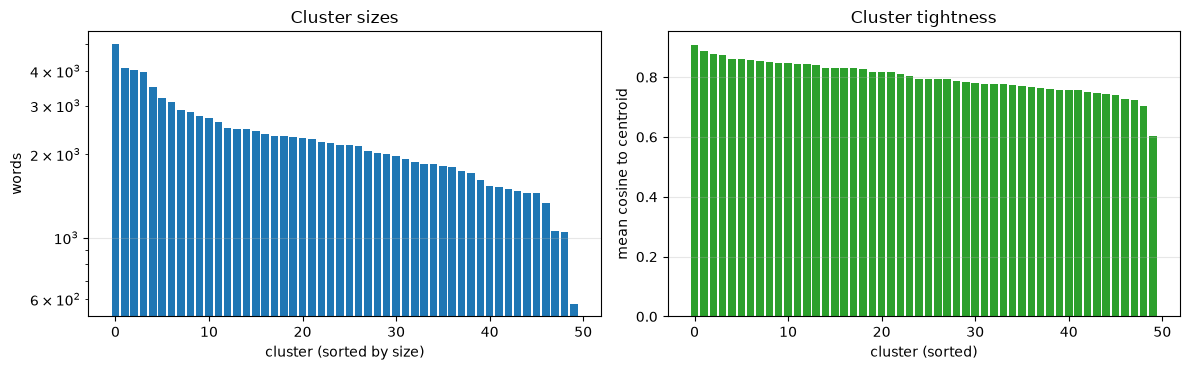

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(range(CONFIG["n_clusters"]), np.sort(sizes)[::-1])
axes[0].set_xlabel("cluster (sorted by size)"); axes[0].set_ylabel("words")
axes[0].set_yscale("log"); axes[0].set_title("Cluster sizes")
axes[0].grid(axis="y", alpha=.3)

# how tight is each cluster? mean cosine similarity of members to their centroid
unit_centroids = l2_normalize(centroids)
tightness = np.array([float(np.mean(W[labels == c] @ unit_centroids[c]))
                      if (labels == c).any() else 0.0
                      for c in range(CONFIG["n_clusters"])])
axes[1].bar(range(CONFIG["n_clusters"]), np.sort(tightness)[::-1], color="tab:green")
axes[1].set_xlabel("cluster (sorted)"); axes[1].set_ylabel("mean cosine to centroid")
axes[1].set_title("Cluster tightness"); axes[1].grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

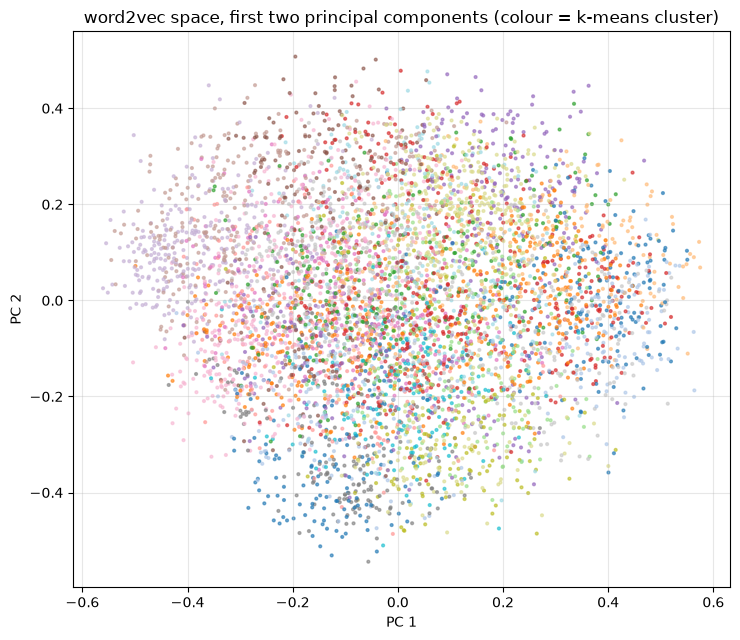

In [22]:
# a 2D view of the embedding space, projected with PCA computed from scratch via the SVD
sample = np.random.RandomState(SEED).choice(W.shape[0], min(6000, W.shape[0]), replace=False)
Xs = W[sample]
Xs = Xs - Xs.mean(axis=0, keepdims=True)
_, _, Vt = np.linalg.svd(Xs, full_matrices=False)
P = Xs @ Vt[:2].T

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(P[:, 0], P[:, 1], c=labels[sample], cmap="tab20", s=4, alpha=.6)
ax.set_title("word2vec space, first two principal components (colour = k-means cluster)")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [23]:
def mean_encode(token_lists, kv, allow_oov):
    """Average of the word vectors. Rows with no usable word come out as zeros."""
    dim = kv.vector_size
    out = np.zeros((len(token_lists), dim), dtype=np.float64)
    empty = 0
    for i, toks in enumerate(token_lists):
        vecs = []
        for w in toks:
            if allow_oov or w in kv.key_to_index:
                try:
                    vecs.append(kv[w])
                except KeyError:
                    continue
        if vecs:
            out[i] = np.mean(vecs, axis=0)
        else:
            empty += 1
    return out, empty


def sif_weighted_average(token_lists, kv, word_freq, total, a=CONFIG["sif_a"]):
    """Smooth inverse frequency weighted average, before the principal component is removed."""
    dim = kv.vector_size
    out = np.zeros((len(token_lists), dim), dtype=np.float64)
    for i, toks in enumerate(token_lists):
        num = np.zeros(dim)
        denom = 0.0
        for w in toks:
            try:
                v = kv[w]
            except KeyError:
                continue
            p = word_freq.get(w, 0) / total
            weight = a / (a + p)
            num += weight * v
            denom += weight
        if denom > 0:
            out[i] = num / denom
    return out


def fit_common_component(X):
    """The first principal component of a set of sentence vectors - the 'generic sentence'
    direction that SIF removes."""
    centred = X - X.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(centred, full_matrices=False)
    return Vt[0]


def remove_component(X, pc):
    """Project out one direction. Queries and the pool MUST have the same direction removed,
    otherwise they no longer live in the same space and similarities are meaningless."""
    return X - np.outer(X @ pc, pc)


def sif_encode(token_lists, kv, word_freq, total, a=CONFIG["sif_a"], pc=None):
    """SIF encoder. Pass `pc` to reuse a component fitted elsewhere (see remove_component)."""
    out = sif_weighted_average(token_lists, kv, word_freq, total, a)
    if pc is not None:
        out = remove_component(out, pc)
    return out


def doc2vec_encode(token_lists, model, epochs=50, seed=SEED):
    """infer_vector for each sentence. Inference is stochastic, so the seed is reset per call."""
    out = np.zeros((len(token_lists), model.vector_size), dtype=np.float64)
    for i, toks in enumerate(token_lists):
        model.random.seed(seed)
        out[i] = model.infer_vector(toks, epochs=epochs)
    return out

In [24]:
# the evaluation pool: validation + test, as the assignment asks for both
EVAL_SENTS = dev_sents + test_sents
EVAL_TOKENS = dev_tokens + test_tokens
EVAL_SPLIT = ["dev"] * len(dev_sents) + ["test"] * len(test_sents)
print("evaluation pool: %d sentences (%d dev + %d test)" %
      (len(EVAL_SENTS), len(dev_sents), len(test_sents)))

# word frequencies for the SIF weights, taken from the training corpus the models saw
FREQ_PATH = os.path.join(DATA_DIR, "train_word_freq.json")
if os.path.exists(FREQ_PATH):
    with io.open(FREQ_PATH, encoding="utf-8") as f:
        word_freq = json.load(f)
else:
    word_freq = Counter()
    for toks in train_corpus:
        word_freq.update(toks)
    word_freq = dict(word_freq)
    with io.open(FREQ_PATH, "w", encoding="utf-8") as f:
        json.dump(word_freq, f, ensure_ascii=False)
TOTAL_FREQ = float(sum(word_freq.values()))
print("word frequency table: {:,} types, {:,.0f} tokens".format(len(word_freq), TOTAL_FREQ))

evaluation pool: 2000 sentences (1000 dev + 1000 test)
word frequency table: 538,928 types, 17,135,144 tokens


In [25]:
ENCODINGS = {}

t0 = time.time()
vecs, empty = mean_encode(EVAL_TOKENS, w2v.wv, allow_oov=False)
ENCODINGS["w2v-mean"] = vecs
print("w2v-mean  : %d sentences with no in-vocabulary word (%.0fs)" % (empty, time.time() - t0))

t0 = time.time()
vecs, empty = mean_encode(EVAL_TOKENS, ft.wv, allow_oov=True)
ENCODINGS["ft-mean"] = vecs
print("ft-mean   : %d empty (%.0fs)" % (empty, time.time() - t0))

t0 = time.time()
_sif_raw = sif_weighted_average(EVAL_TOKENS, ft.wv, word_freq, TOTAL_FREQ)
# fit the common component ONCE on the pool and keep it, so queries in section 8 can have the
# very same direction removed
SIF_PC = fit_common_component(_sif_raw)
ENCODINGS["ft-SIF"] = remove_component(_sif_raw, SIF_PC)
print("ft-SIF    : done (%.0fs)" % (time.time() - t0))

t0 = time.time()
ENCODINGS["doc2vec"] = doc2vec_encode(EVAL_TOKENS, d2v)
print("doc2vec   : done (%.0fs)" % (time.time() - t0))

for name, M in ENCODINGS.items():
    print("%-10s shape %s" % (name, M.shape))

w2v-mean  : 0 sentences with no in-vocabulary word (0s)
ft-mean   : 0 empty (0s)
ft-SIF    : done (0s)
doc2vec   : done (6s)
w2v-mean   shape (2000, 100)
ft-mean    shape (2000, 100)
ft-SIF     shape (2000, 100)
doc2vec    shape (2000, 100)


In [26]:
def nearest_sentences(M):
    """Return (index of nearest other sentence, its cosine similarity) for every row.

    A row that is all zeros - a sentence in which every word was out of vocabulary - has no
    meaningful neighbour, so those are reported rather than silently returning whatever
    argmax happens to pick out of a row of zeros.
    """
    dead = np.flatnonzero(np.linalg.norm(M, axis=1) == 0)
    U = l2_normalize(M)
    S = U @ U.T
    np.fill_diagonal(S, -np.inf)
    nn = np.argmax(S, axis=1)
    sim = S[np.arange(S.shape[0]), nn]
    return nn, sim, dead


NEIGHBOURS = {}
for name, M in ENCODINGS.items():
    nn, sim, dead = nearest_sentences(M)
    NEIGHBOURS[name] = (nn, sim)
    note = "" if dead.size == 0 else "  [%d sentence(s) had no usable word]" % dead.size
    print("%-10s mean nearest-neighbour cosine %.4f  (median %.4f)%s" %
          (name, float(np.mean(sim)), float(np.median(sim)), note))

w2v-mean   mean nearest-neighbour cosine 0.9025  (median 0.9079)
ft-mean    mean nearest-neighbour cosine 0.9034  (median 0.9071)
ft-SIF     mean nearest-neighbour cosine 0.8772  (median 0.8804)
doc2vec    mean nearest-neighbour cosine 0.5378  (median 0.5105)


In [27]:
def show_pairs(name, n=CONFIG["n_examples"], indices=None):
    nn, sim = NEIGHBOURS[name]
    if indices is None:
        # show the most confident matches - they are the most informative to read
        indices = np.argsort(-sim)[:n]
    print("=" * 100)
    print("%s - closest sentence for a few queries" % name)
    print("=" * 100)
    for i in indices:
        j = nn[i]
        print("[%s #%d]  %s" % (EVAL_SPLIT[i], i, EVAL_SENTS[i]))
        print("   -> [%s #%d] cos %.3f  %s" % (EVAL_SPLIT[j], j, sim[i], EVAL_SENTS[j]))
        print()


for name in ENCODINGS:
    show_pairs(name)

w2v-mean - closest sentence for a few queries
[dev #303]  આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.
   -> [test #1085] cos 0.994  આ સાથે રાજ્યમાં અત્યાર સુધીમાં 62,10,550 ટેસ્ટ કરવામાં આવ્યા છે.

[test #1085]  આ સાથે રાજ્યમાં અત્યાર સુધીમાં 62,10,550 ટેસ્ટ કરવામાં આવ્યા છે.
   -> [dev #303] cos 0.994  આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.

[test #1108]  લાલપુર) ભારત દેશના પશ્ચિમ ભાગમાં આવેલા ગુજરાત રાજ્યના સૌરાષ્ટ્ર વિસ્તારમાં આવેલા જામનગર જિલ્લામાં આવેલા કુલ ૬ (છ) તાલુકાઓ પૈકીના એક એવા લાલપુર તાલુકામાં આવેલું એક ગામ છે.
   -> [test #1017] cos 0.989  મોટી તંબાડી ભારત દેશના પશ્ચિમ ભાગમાં આવેલા ગુજરાત રાજ્યના દક્ષિણ ભાગમાં આવેલા વલસાડ જિલ્લામાં આવેલા કુલ ૬ (છ) તાલુકાઓ પૈકીના એક એવા વાપી તાલુકામાં આવેલું એક ગામ છે.

[test #1017]  મોટી તંબાડી ભારત દેશના પશ્ચિમ ભાગમાં આવેલા ગુજરાત રાજ્યના દક્ષિણ ભાગમાં આવેલા વલસાડ જિલ્લામાં આવેલા કુલ ૬ (છ) તાલુકાઓ પૈકીના એક એવા વાપી તાલુકામાં આવેલું એક ગામ છે.
   -> [test #1108] cos 0.989  લાલપુર) ભારત દેશના

In [28]:
# the same query sentences under all four encoders, so the differences are directly comparable
query_idx = np.argsort(-NEIGHBOURS["ft-SIF"][1])[:CONFIG["n_examples"]]
for i in query_idx:
    print("=" * 100)
    print("[%s #%d] %s" % (EVAL_SPLIT[i], i, EVAL_SENTS[i]))
    print("-" * 100)
    for name in ENCODINGS:
        nn, sim = NEIGHBOURS[name]
        j = nn[i]
        print("  %-9s cos %.3f  [%s #%d] %s" % (name, sim[i], EVAL_SPLIT[j], j,
                                                EVAL_SENTS[j][:80]))
    print()

[test #1085] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 62,10,550 ટેસ્ટ કરવામાં આવ્યા છે.
----------------------------------------------------------------------------------------------------
  w2v-mean  cos 0.994  [dev #303] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.
  ft-mean   cos 0.994  [dev #303] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.
  ft-SIF    cos 0.986  [dev #303] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.
  doc2vec   cos 0.882  [dev #303] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.

[dev #303] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 13,58,364 ટેસ્ટ કરવામાં આવ્યા છે.
----------------------------------------------------------------------------------------------------
  w2v-mean  cos 0.994  [test #1085] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 62,10,550 ટેસ્ટ કરવામાં આવ્યા છે.
  ft-mean   cos 0.994  [test #1085] આ સાથે રાજ્યમાં અત્યાર સુધીમાં 62,10,550 ટેસ્ટ કરવામાં આવ્યા છે.
  ft-SIF    cos 0.986  [test #1085] આ સાથે રા

In [29]:
# save every (sentence, closest sentence) pair
records = []
for i in range(len(EVAL_SENTS)):
    rec = {"index": i, "split": EVAL_SPLIT[i], "sentence": EVAL_SENTS[i], "closest": {}}
    for name in ENCODINGS:
        nn, sim = NEIGHBOURS[name]
        rec["closest"][name] = {"index": int(nn[i]),
                                "cosine": round(float(sim[i]), 4),
                                "sentence": EVAL_SENTS[nn[i]]}
    records.append(rec)
with io.open(os.path.join(DATA_DIR, "closest_sentences.json"), "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=1)
print("saved {:,} query/neighbour records -> {}".format(
    len(records), os.path.join(DATA_DIR, "closest_sentences.json")))

saved 2,000 query/neighbour records -> data\closest_sentences.json


In [30]:
names = list(ENCODINGS)
print("%-10s" % "", end="")
for b in names:
    print("%10s" % b, end="")
print()
print("-" * (10 + 10 * len(names)))
agreement = np.zeros((len(names), len(names)))
for a, na in enumerate(names):
    print("%-10s" % na, end="")
    for b, nb in enumerate(names):
        same = float(np.mean(NEIGHBOURS[na][0] == NEIGHBOURS[nb][0]))
        agreement[a, b] = same
        print("%9.1f%%" % (100 * same), end="")
    print()
print("\n(percentage of the 2000 queries where the two encoders pick the same nearest sentence)")

            w2v-mean   ft-mean    ft-SIF   doc2vec
--------------------------------------------------
w2v-mean      100.0%     55.1%     30.6%      3.9%
ft-mean        55.1%    100.0%     47.1%      3.2%
ft-SIF         30.6%     47.1%    100.0%      3.0%
doc2vec         3.9%      3.2%      3.0%    100.0%

(percentage of the 2000 queries where the two encoders pick the same nearest sentence)


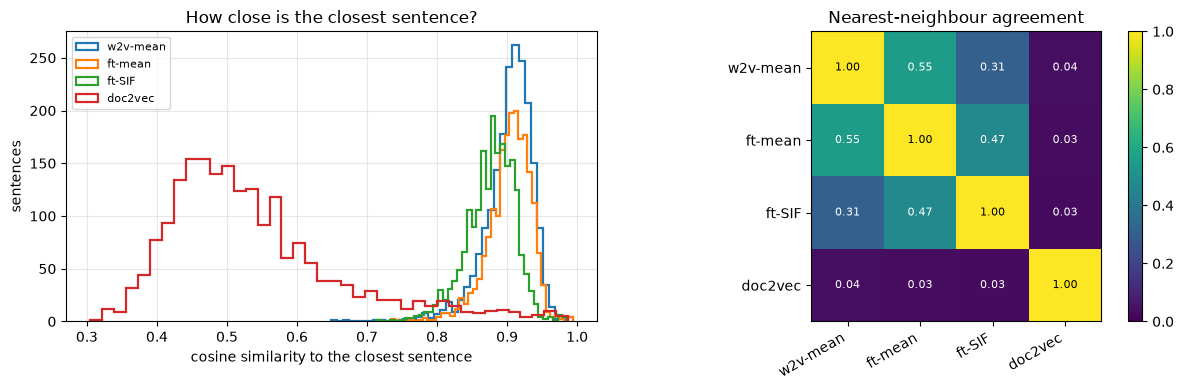

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name in ENCODINGS:
    ax[0].hist(NEIGHBOURS[name][1], bins=40, histtype="step", lw=1.6, label=name)
ax[0].set_xlabel("cosine similarity to the closest sentence")
ax[0].set_ylabel("sentences"); ax[0].set_title("How close is the closest sentence?")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

im = ax[1].imshow(agreement, cmap="viridis", vmin=0, vmax=1)
ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels(names, rotation=30, ha="right")
ax[1].set_yticks(range(len(names))); ax[1].set_yticklabels(names)
ax[1].set_title("Nearest-neighbour agreement")
for a in range(len(names)):
    for b in range(len(names)):
        ax[1].text(b, a, "%.2f" % agreement[a, b], ha="center", va="center",
                   color="w" if agreement[a, b] < 0.6 else "k", fontsize=8)
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

In [32]:
def perturb(tokens, rng, drop=0.25):
    kept = [w for w in tokens if rng.random() > drop]
    if len(kept) < 2:
        kept = list(tokens)
    # a light local shuffle: swap a couple of adjacent pairs
    kept = list(kept)
    for _ in range(max(1, len(kept) // 6)):
        i = rng.randrange(max(1, len(kept) - 1))
        kept[i], kept[i + 1] = kept[i + 1], kept[i]
    return kept


rng = random.Random(SEED)
n_probe = min(CONFIG["paraphrase_probe_n"], len(EVAL_TOKENS))
probe_idx = rng.sample(range(len(EVAL_TOKENS)), n_probe)
probe_tokens = [perturb(EVAL_TOKENS[i], rng) for i in probe_idx]

print("probing with %d perturbed sentences (25%% of words dropped, some adjacent swaps)\n" %
      n_probe)
print("example original :", " ".join(EVAL_TOKENS[probe_idx[0]]))
print("example perturbed:", " ".join(probe_tokens[0]))

probing with 500 perturbed sentences (25% of words dropped, some adjacent swaps)

example original : ઉમર ફારુક ખાન , ઈસ્લામાબાદઃ સંયુક્ત રાષ્ટ્રમાં ભડકાઉ પ્રદર્શન માટે ઈમરાન ખાનની ભલે ટીકા થઈ રહી હોય પરંતુ તે આને પોતાની ઉપલબ્ધિ ગણી ફૂલ્યા સમાતા નથી .
example perturbed: ફારુક ઉમર ખાન સંયુક્ત રાષ્ટ્રમાં પ્રદર્શન ભડકાઉ માટે ભલે ટીકા થઈ રહી હોય ઉપલબ્ધિ પોતાની ગણી ફૂલ્યા નથી .


In [33]:
def encode_like(name, token_lists):
    if name == "w2v-mean":
        return mean_encode(token_lists, w2v.wv, allow_oov=False)[0]
    if name == "ft-mean":
        return mean_encode(token_lists, ft.wv, allow_oov=True)[0]
    if name == "ft-SIF":
        # the SAME common component that was removed from the pool
        return sif_encode(token_lists, ft.wv, word_freq, TOTAL_FREQ, pc=SIF_PC)
    if name == "doc2vec":
        return doc2vec_encode(token_lists, d2v)
    raise ValueError(name)


print("%-10s %10s %10s %12s" % ("encoder", "Recall@1", "Recall@5", "mean rank"))
print("-" * 44)
probe_results = {}
for name in ENCODINGS:
    Q = l2_normalize(encode_like(name, probe_tokens))
    P = l2_normalize(ENCODINGS[name])
    S = Q @ P.T
    order = np.argsort(-S, axis=1)
    gold = np.asarray(probe_idx)
    ranks = np.array([int(np.flatnonzero(order[r] == gold[r])[0]) for r in range(n_probe)])
    r1 = float(np.mean(ranks == 0))
    r5 = float(np.mean(ranks < 5))
    probe_results[name] = {"recall@1": r1, "recall@5": r5, "mean_rank": float(ranks.mean())}
    print("%-10s %9.1f%% %9.1f%% %12.1f" % (name, 100 * r1, 100 * r5, ranks.mean()))

print("\n(chance Recall@1 would be %.2f%%)" % (100.0 / len(EVAL_SENTS)))

encoder      Recall@1   Recall@5    mean rank
--------------------------------------------
w2v-mean        98.8%      99.4%          0.3
ft-mean         99.8%      99.8%          0.0
ft-SIF          99.0%      99.6%          0.0
doc2vec         91.6%      94.4%         13.4

(chance Recall@1 would be 0.05%)


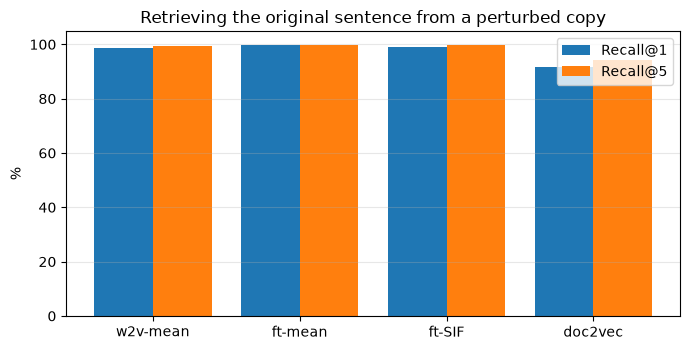

In [34]:
fig, ax = plt.subplots(figsize=(7, 3.6))
xs = np.arange(len(probe_results))
ax.bar(xs - 0.2, [100 * probe_results[n]["recall@1"] for n in probe_results], 0.4,
       label="Recall@1")
ax.bar(xs + 0.2, [100 * probe_results[n]["recall@5"] for n in probe_results], 0.4,
       label="Recall@5")
ax.set_xticks(xs); ax.set_xticklabels(list(probe_results))
ax.set_ylabel("%"); ax.set_title("Retrieving the original sentence from a perturbed copy")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

In [35]:
with io.open(os.path.join(DATA_DIR, "encoder_comparison.json"), "w", encoding="utf-8") as f:
    json.dump({"probe": probe_results,
               "mean_nn_cosine": {n: float(np.mean(NEIGHBOURS[n][1])) for n in ENCODINGS},
               "agreement": {names[a]: {names[b]: float(agreement[a, b])
                                        for b in range(len(names))}
                             for a in range(len(names))}},
              f, ensure_ascii=False, indent=1)
print("saved ->", os.path.join(DATA_DIR, "encoder_comparison.json"))

saved -> data\encoder_comparison.json
